# Paso 1: Filtrado Base

In [1]:
import pandas as pd

# 1. Cargar nuestra Capa 
ruta_entrada = "../data/processed/dataset_completo.parquet"
print("Cargando el histórico masivo de 9.6M de registros...")
df_plata = pd.read_parquet(ruta_entrada)

# 2. Definir los 4 IDs de los sensores cardinales (Norte, Sur, Este, Oeste)
ids_cardinales = [6775, 6679, 3819, 1018]

# 3. Aplicar Filtro Espacial (Solo los 4 sensores)
print("Filtrando sensores cardinales...")
df_oro = df_plata[df_plata['id'].isin(ids_cardinales)].copy()

# 4. Aplicar Filtro Temporal 
print("Filtrando histórico (>= 2024)...")
# Al ser formato datetime, Pandas permite filtrar usando un string ISO
df_oro = df_oro[df_oro['fecha'] >= '2024-01-01']

# 5. Eliminar la variable 'carga'
print("Eliminando la variable algorítmica 'carga'...")
# Usamos errors='ignore' para que no falle si ejecuto la celda por accidente dos veces
df_oro = df_oro.drop(columns=['carga'], errors='ignore')

# 6. Validación de resultados
print("\n--- RESUMEN DEL PASO 1 ---")
print(f"Sensores finales: {df_oro['id'].unique()}")
print(f"Fecha mínima validada: {df_oro['fecha'].min()}")
print(f"Columnas disponibles: {list(df_oro.columns)}")
print(f"Total de registros útiles: {len(df_oro)}")

Cargando el histórico masivo de 9.6M de registros...
Filtrando sensores cardinales...
Filtrando histórico (>= 2024)...
Eliminando la variable algorítmica 'carga'...

--- RESUMEN DEL PASO 1 ---
Sensores finales: [1018 3819 6679 6775]
Fecha mínima validada: 2024-01-01 00:00:00
Columnas disponibles: ['id', 'fecha', 'intensidad', 'ocupacion', 'vmed']
Total de registros útiles: 65485


# Paso 2: Agregamos dia de la semana

In [2]:
print("Extrayendo variables temporales predictivas...")

# 1. Extraer día de la semana numérico (0=Lunes, 6=Domingo), la hora y el mes
df_oro['dia_semana_num'] = df_oro['fecha'].dt.dayofweek
df_oro['hora'] = df_oro['fecha'].dt.hour
df_oro['mes_num'] = df_oro['fecha'].dt.month

# 2. Mapeo a nombres legibles para la visualización exploratoria (EDA)
dias_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
meses_map = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
             7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}

df_oro['dia_semana'] = df_oro['dia_semana_num'].map(dias_map)
df_oro['mes'] = df_oro['mes_num'].map(meses_map)

# 3. Convertir a categorías ordenadas
# Esto evita que Matplotlib/Seaborn ordenen los gráficos alfabéticamente
df_oro['dia_semana'] = pd.Categorical(df_oro['dia_semana'], categories=list(dias_map.values()), ordered=True)
df_oro['mes'] = pd.Categorical(df_oro['mes'], categories=list(meses_map.values()), ordered=True)

# 4. Mapeo de IDs a Puntos Cardinales
cardinales_map = {
    1018: 'Oeste',
    3819: 'Este',
    6679: 'Sur',
    6775: 'Norte'
}
df_oro['ubicacion'] = df_oro['id'].map(cardinales_map)

# 5. Validación
print("\n--- RESUMEN DEL PASO 2 ---")
print("Muestra de las nuevas características temporales y espaciales:")
print(df_oro[['fecha', 'ubicacion', 'dia_semana', 'hora', 'mes', 'intensidad']].head())
print("\n¿Hay algún valor nulo en las nuevas columnas?:")
print(df_oro[['dia_semana', 'hora', 'ubicacion', 'mes']].isnull().sum())

Extrayendo variables temporales predictivas...

--- RESUMEN DEL PASO 2 ---
Muestra de las nuevas características temporales y espaciales:
                     fecha ubicacion dia_semana  hora    mes  intensidad
190622 2024-01-01 00:00:00     Oeste      Lunes     0  Enero       628.0
190623 2024-01-01 01:00:00     Oeste      Lunes     1  Enero      3111.0
190624 2024-01-01 02:00:00     Oeste      Lunes     2  Enero      2943.0
190625 2024-01-01 03:00:00     Oeste      Lunes     3  Enero      1482.0
190626 2024-01-01 04:00:00     Oeste      Lunes     4  Enero       675.0

¿Hay algún valor nulo en las nuevas columnas?:
dia_semana    0
hora          0
ubicacion     0
mes           0
dtype: int64


In [3]:
print(df_oro.tail())

           id               fecha  intensidad  ocupacion   vmed  \
5703457  6775 2026-02-28 19:00:00     2385.50       5.75  82.75   
5703458  6775 2026-02-28 20:00:00     2449.50       5.50  83.00   
5703459  6775 2026-02-28 21:00:00     2114.50       5.00  84.25   
5703460  6775 2026-02-28 22:00:00     1353.25       3.00  88.25   
5703461  6775 2026-02-28 23:00:00     1101.50       1.75  88.00   

         dia_semana_num  hora  mes_num dia_semana      mes ubicacion  
5703457               5    19        2     Sábado  Febrero     Norte  
5703458               5    20        2     Sábado  Febrero     Norte  
5703459               5    21        2     Sábado  Febrero     Norte  
5703460               5    22        2     Sábado  Febrero     Norte  
5703461               5    23        2     Sábado  Febrero     Norte  


# Paso 3: Analisis exploratorio de datos

Generando visualizaciones académicas...


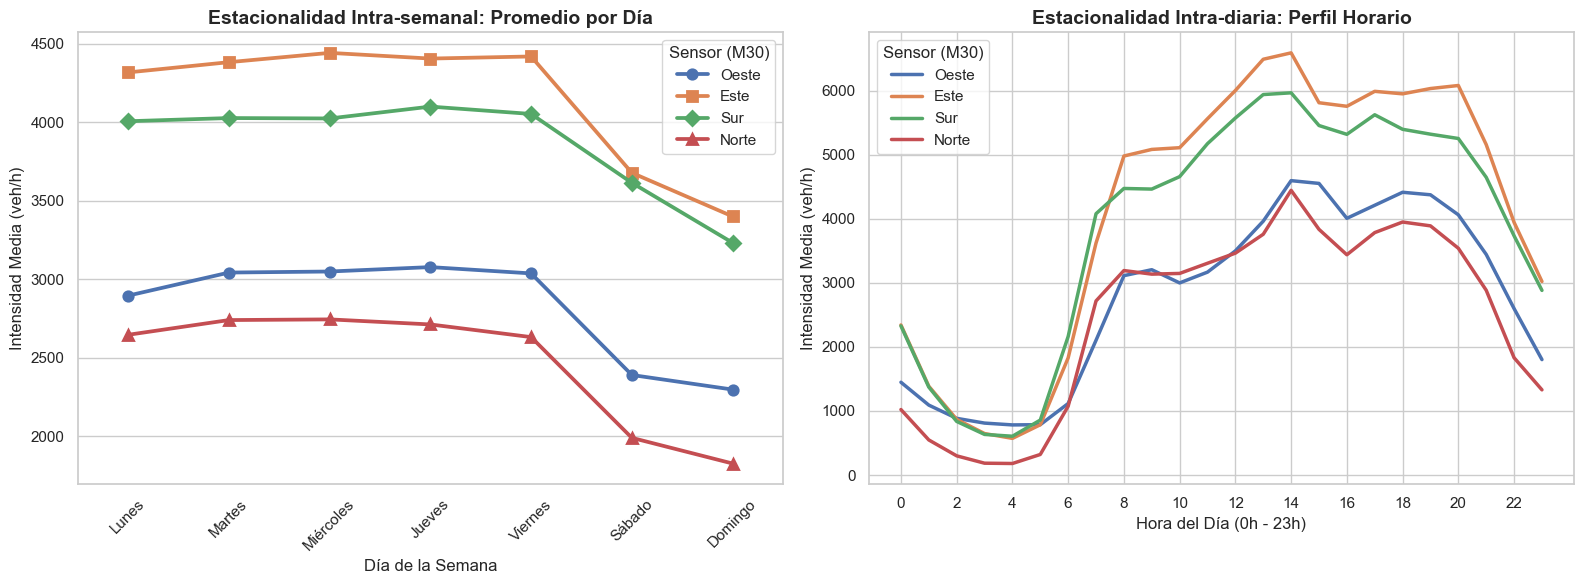

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando visualizaciones académicas...")

# 1. Configurar el estilo del gráfico (estilo profesional/académico)
sns.set_theme(style="whitegrid", context="notebook")

# 2. Crear una figura con 2 subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Comportamiento Semanal ---
# Usamos pointplot para enfatizar el valor medio de cada día
sns.pointplot(
    data=df_oro, 
    x='dia_semana', 
    y='intensidad', 
    hue='ubicacion', 
    ax=axes[0],
    errorbar=None, # Ocultamos la varianza para ver limpia la tendencia central
    markers=['o', 's', 'D', '^']
)
axes[0].set_title('Estacionalidad Intra-semanal: Promedio por Día', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Día de la Semana', fontsize=12)
axes[0].set_ylabel('Intensidad Media (veh/h)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Sensor (M30)')

# --- GRÁFICO 2: Comportamiento Diario (Horas Punta) ---
# Usamos lineplot para ver la fluidez del paso de las horas
sns.lineplot(
    data=df_oro, 
    x='hora', 
    y='intensidad', 
    hue='ubicacion', 
    ax=axes[1],
    errorbar=None,
    linewidth=2.5
)
axes[1].set_title('Estacionalidad Intra-diaria: Perfil Horario', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hora del Día (0h - 23h)', fontsize=12)
axes[1].set_ylabel('Intensidad Media (veh/h)', fontsize=12)
axes[1].set_xticks(range(0, 24, 2)) # Mostrar ticks cada 2 horas
axes[1].legend(title='Sensor (M30)')

# Ajustar el espaciado y mostrar
plt.tight_layout()
plt.show()

Primera semana: 2024-01-01 → 2024-01-08
Registros: 168


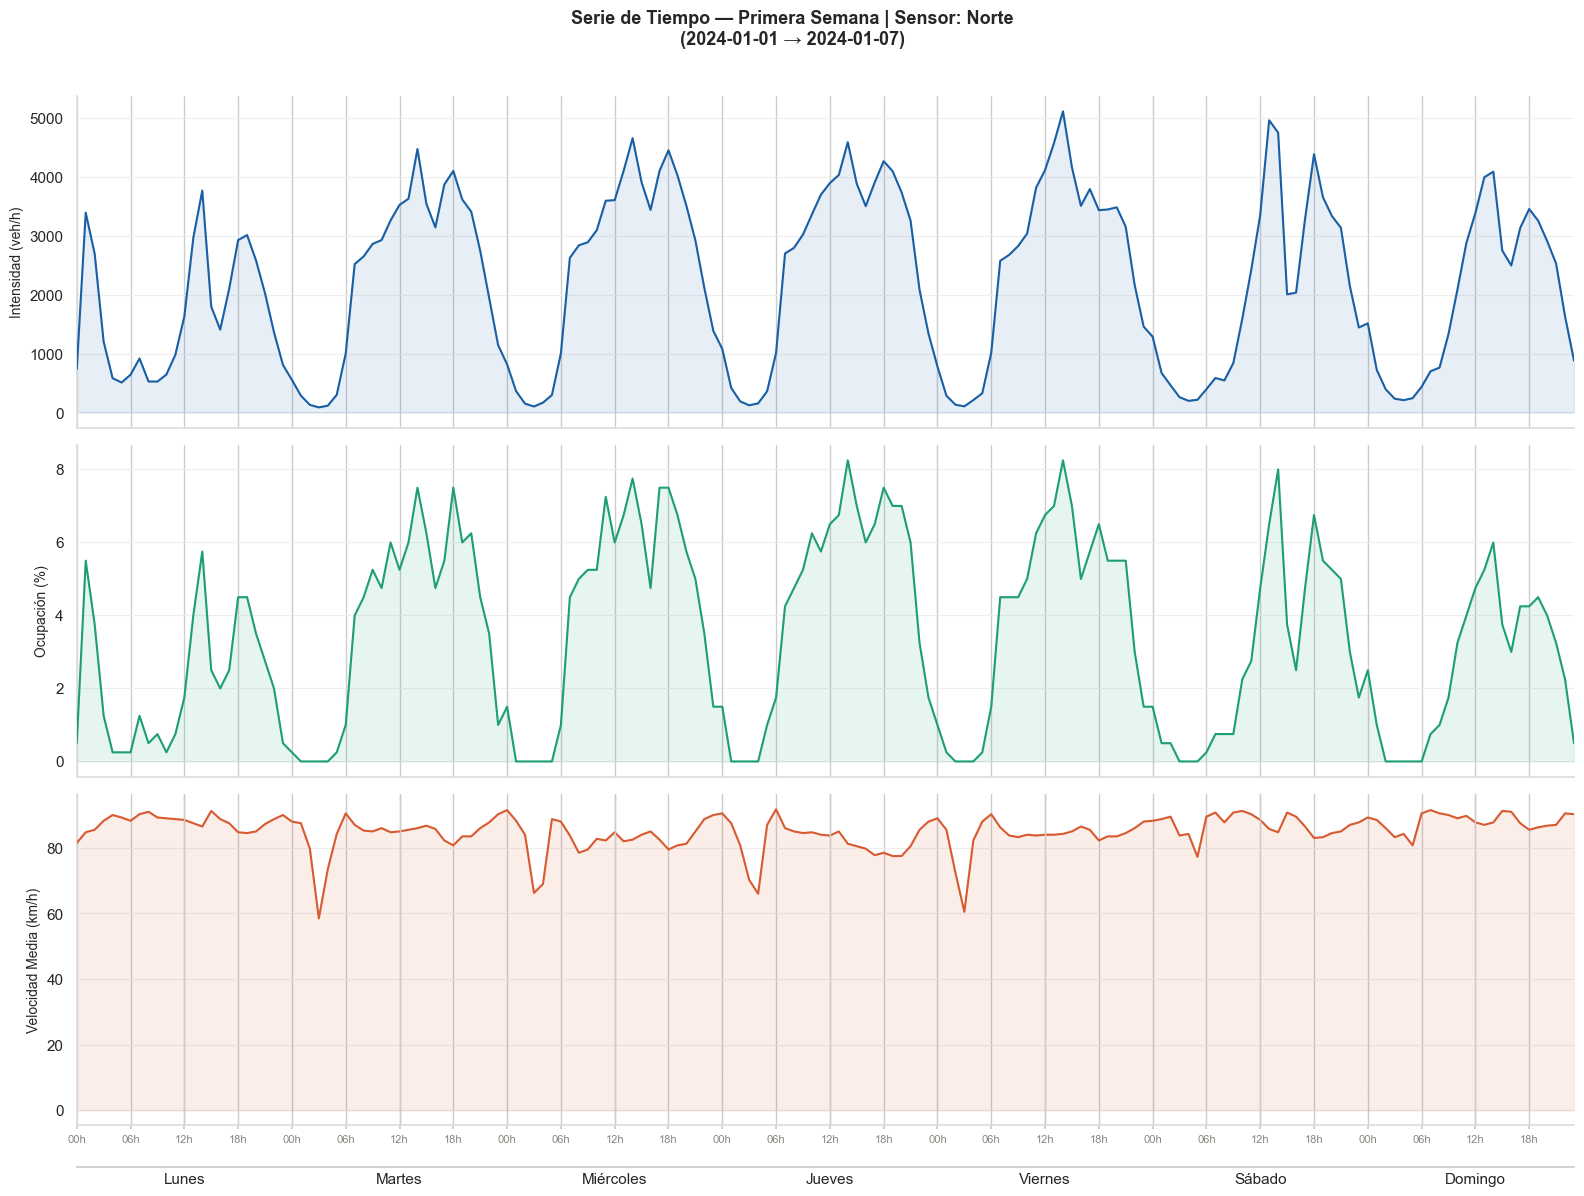

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURACIÓN ---
UBICACION_FILTRO = 'Norte'
COLORES = {
    'intensidad': '#185FA5',
    'ocupacion':  '#1D9E75',
    'vmed':       '#D85A30'
}
LABELS = {
    'intensidad': 'Intensidad (veh/h)',
    'ocupacion':  'Ocupación (%)',
    'vmed':       'Velocidad Media (km/h)'
}

# --- FILTRAR POR UBICACIÓN ---
df_sensor = df_oro[df_oro['ubicacion'] == UBICACION_FILTRO].copy()

# --- PRIMERA SEMANA: desde el primer lunes disponible hasta 7 días después ---
primer_registro = df_sensor['fecha'].min()
# Retroceder hasta el lunes de esa semana
primer_lunes = primer_registro - pd.Timedelta(days=primer_registro.dayofweek)
primer_lunes = primer_lunes.normalize()  # a medianoche
ultimo_dia = primer_lunes + pd.Timedelta(days=7)

df_semana = (
    df_sensor[(df_sensor['fecha'] >= primer_lunes) & (df_sensor['fecha'] < ultimo_dia)]
    .sort_values('fecha')
    .reset_index(drop=True)
)

print(f"Primera semana: {primer_lunes.date()} → {ultimo_dia.date()}")
print(f"Registros: {len(df_semana)}")

# --- DATOS PARA EL EJE X ---
# Reutilizamos dias_map del Paso 2
dias_orden = list(dias_map.values())
horas_por_dia = 24
n_dias = len(dias_orden)
total_puntos = n_dias * horas_por_dia
x = np.arange(total_puntos)

# Construimos un índice global hora a hora para alinear los datos reales
# (puede haber huecos si faltan registros en alguna hora)
idx_completo = pd.MultiIndex.from_product(
    [range(n_dias), range(horas_por_dia)],
    names=['dia_semana_num', 'hora']
)
df_semana_pivot = (
    df_semana
    .groupby(['dia_semana_num', 'hora'])[['intensidad', 'ocupacion', 'vmed']]
    .mean()
    .reindex(idx_completo)  # rellena con NaN si falta alguna hora
)

# --- FIGURA: 3 subgráficos apilados verticalmente ---
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(
    f'Serie de Tiempo — Primera Semana | Sensor: {UBICACION_FILTRO}\n'
    f'({primer_lunes.date()} → {(ultimo_dia - pd.Timedelta(days=1)).date()})',
    fontsize=13, fontweight='bold', y=1.01
)

for ax, variable in zip(axes, ['intensidad', 'ocupacion', 'vmed']):
    valores = df_semana_pivot[variable].values
    color   = COLORES[variable]

    ax.plot(x, valores, color=color, linewidth=1.5, zorder=3)
    ax.fill_between(x, valores, alpha=0.10, color=color, zorder=2)

    # Separadores verticales entre días
    for d in range(1, n_dias):
        ax.axvline(x=d * horas_por_dia, color='#cccccc', linewidth=0.8, linestyle='--', zorder=1)

    # Estética por subgráfico
    ax.set_ylabel(LABELS[variable], fontsize=10)
    ax.set_xlim(0, total_puntos - 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
    ax.set_axisbelow(True)

# --- EJE X: horas (solo en el último subgráfico, gracias a sharex=True) ---
tick_positions = [d * horas_por_dia + h for d in range(n_dias) for h in range(0, horas_por_dia, 6)]
tick_labels    = [f'{h:02d}h' for _ in range(n_dias) for h in range(0, horas_por_dia, 6)]

axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_labels, fontsize=8, color='#888780')
axes[-1].tick_params(axis='x', length=3, color='#cccccc')

# --- EJE SECUNDARIO: nombres de días agrupados debajo del último subgráfico ---
ax2 = axes[-1].twiny()
ax2.set_xlim(axes[-1].get_xlim())

centros_dias = [d * horas_por_dia + horas_por_dia / 2 for d in range(n_dias)]
ax2.set_xticks(centros_dias)
ax2.set_xticklabels(dias_orden, fontsize=10, fontweight='bold', color='#444441')

ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 30))
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='x', length=0)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="notebook")

# --- FILTRO: solo sensor Norte ---
df_norte = df_oro[df_oro['ubicacion'] == 'Norte'].copy()
if 'dia_mes' not in df_norte.columns:
    df_norte['dia_mes'] = df_norte['fecha'].dt.day

dias_orden = list(dias_map.values())

# --- PERIODOS ---
primer_dia        = df_norte['fecha'].dt.normalize().min()
primer_lunes      = primer_dia - pd.Timedelta(days=primer_dia.dayofweek)
ultimo_domingo    = primer_lunes + pd.Timedelta(days=7)
primer_mes_inicio = primer_dia.replace(day=1)
primer_mes_fin    = (primer_mes_inicio + pd.offsets.MonthEnd(1)).normalize() + pd.Timedelta(days=1)
dias_en_mes       = (primer_mes_fin - primer_mes_inicio).days
primer_anio       = primer_dia.year

# --- AGREGADOS (media y std por unidad temporal) ---

# Intra-semanal: media y std por día de la semana
df_semana_agg = (
    df_norte[(df_norte['fecha'] >= primer_lunes) & (df_norte['fecha'] < ultimo_domingo)]
    .groupby('dia_semana_num')[['intensidad', 'ocupacion', 'vmed']]
    .agg(['mean', 'std'])
    .reindex(range(7))
)

# Intra-mensual: media y std por día del mes
df_mes_agg = (
    df_norte[(df_norte['fecha'] >= primer_mes_inicio) & (df_norte['fecha'] < primer_mes_fin)]
    .groupby('dia_mes')[['intensidad', 'ocupacion', 'vmed']]
    .agg(['mean', 'std'])
    .reindex(range(1, dias_en_mes + 1))
)

# Mensual: media y std por mes
df_anio_agg = (
    df_norte[df_norte['fecha'].dt.year == primer_anio]
    .groupby('mes_num')[['intensidad', 'ocupacion', 'vmed']]
    .agg(['mean', 'std'])
    .reindex(range(1, 13))
)

variables = {
    'intensidad': ('Intensidad (veh/h)',     '#185FA5'),
    'ocupacion':  ('Ocupación (%)',          '#1D9E75'),
    'vmed':       ('Velocidad Media (km/h)', '#D85A30'),
}

print("✅ Datos preparados. Ejecuta las celdas siguientes para cada perfil.")

✅ Datos preparados. Ejecuta las celdas siguientes para cada perfil.


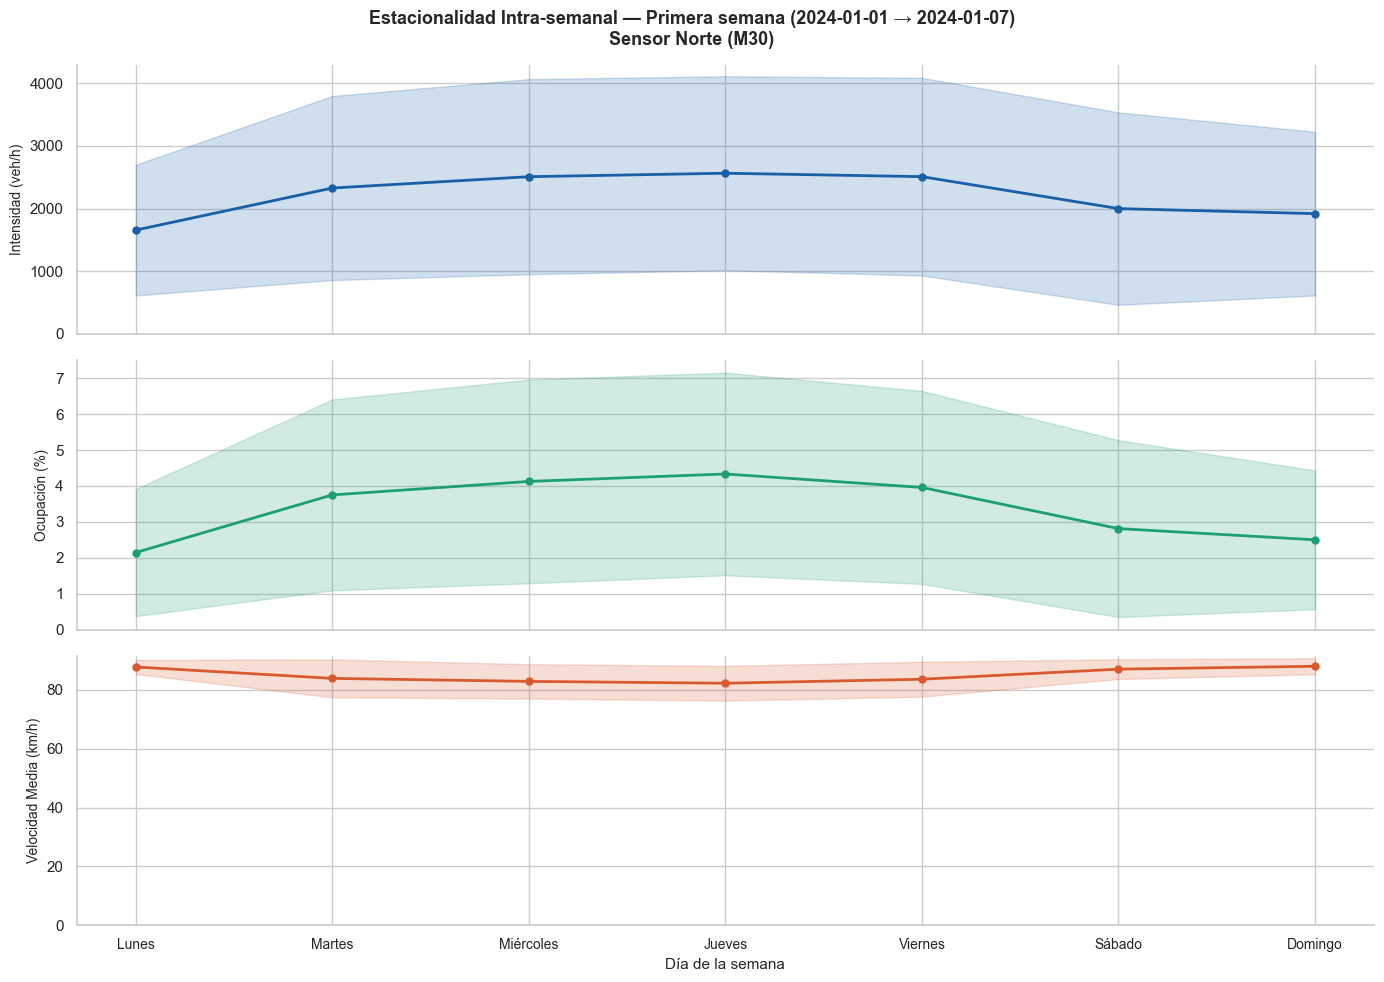

In [7]:
# Visualización Promediando los datos de solo un periodo.
# Estacionalidad Intra-semanal — Primera semana
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Estacionalidad Intra-semanal — Primera semana '
             f'({primer_lunes.date()} → {(ultimo_domingo - pd.Timedelta(days=1)).date()})\nSensor Norte (M30)',
             fontsize=13, fontweight='bold')

for row, (var, (label, color)) in enumerate(variables.items()):
    ax    = axes[row]
    media = df_semana_agg[(var, 'mean')].values
    std   = df_semana_agg[(var, 'std')].values
    x     = np.arange(7)

    ax.fill_between(x, media - std, media + std, alpha=0.20, color=color)
    ax.plot(x, media, color=color, linewidth=2, marker='o', markersize=5, zorder=3)

    ax.set_ylim(bottom=0)
    ax.set_ylabel(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xticks(range(7))
axes[-1].set_xticklabels(dias_orden, fontsize=10)
axes[-1].set_xlabel('Día de la semana', fontsize=11)

plt.tight_layout()
plt.show()

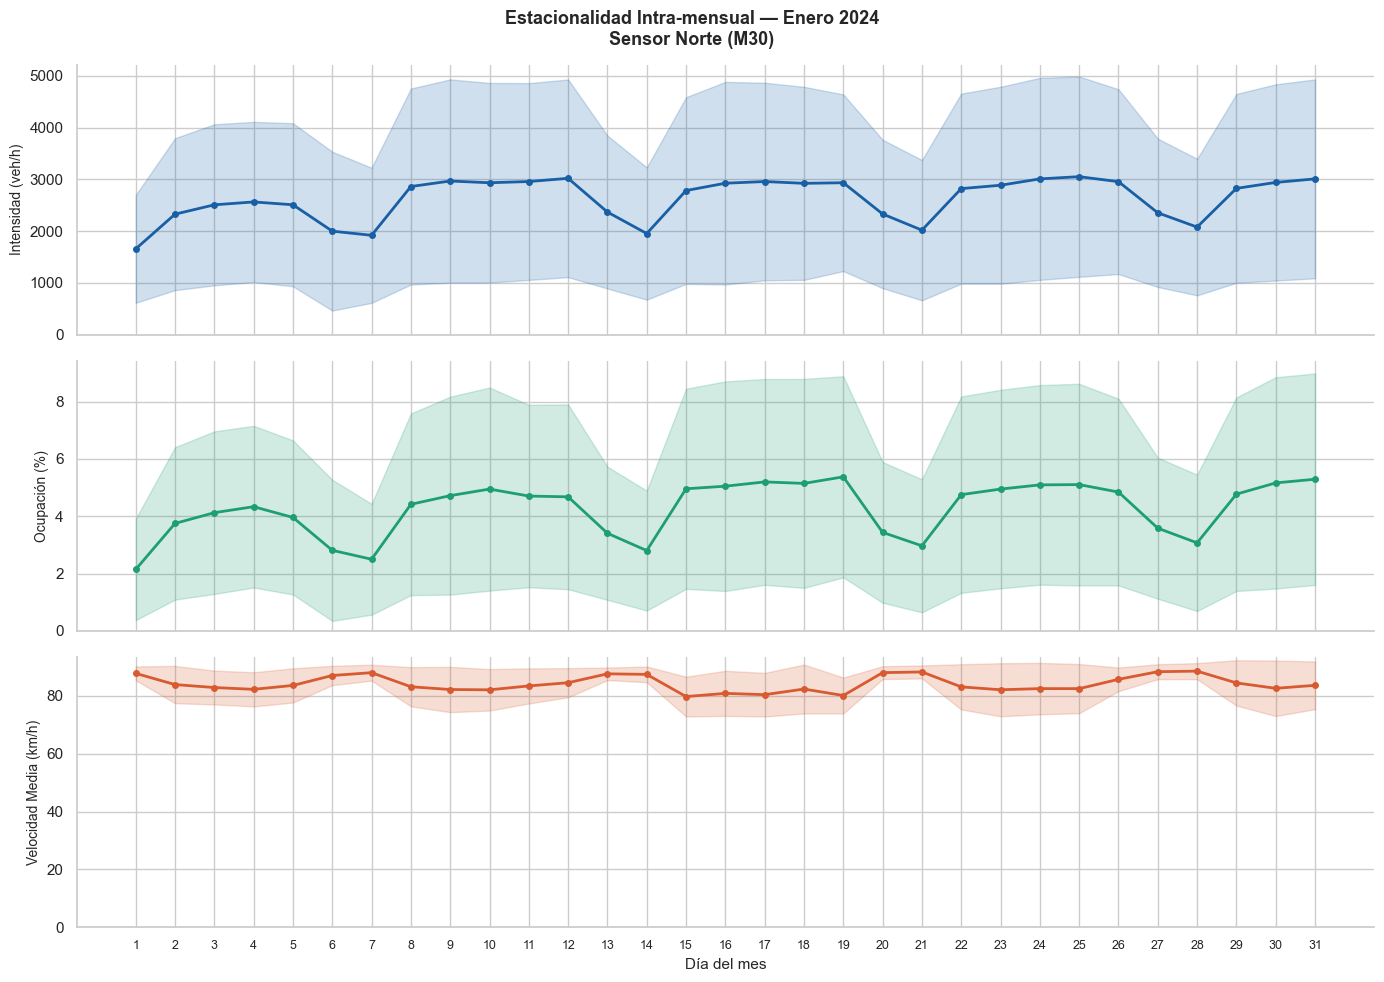

In [8]:
# Visualización Promediando los datos de solo un periodo.
# Estacionalidad Intra-mensual — Primer mes
mes_nombre = list(meses_map.values())[primer_mes_inicio.month - 1]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Estacionalidad Intra-mensual — {mes_nombre} {primer_anio}\nSensor Norte (M30)',
             fontsize=13, fontweight='bold')

for row, (var, (label, color)) in enumerate(variables.items()):
    ax    = axes[row]
    media = df_mes_agg[(var, 'mean')].values
    std   = df_mes_agg[(var, 'std')].values
    x     = np.arange(1, dias_en_mes + 1)

    ax.fill_between(x, media - std, media + std, alpha=0.20, color=color)
    ax.plot(x, media, color=color, linewidth=2, marker='o', markersize=4, zorder=3)

    ax.set_ylim(bottom=0)
    ax.set_ylabel(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xticks(range(1, dias_en_mes + 1))
axes[-1].set_xticklabels([str(d) for d in range(1, dias_en_mes + 1)], fontsize=9)
axes[-1].set_xlabel('Día del mes', fontsize=11)

plt.tight_layout()
plt.show()

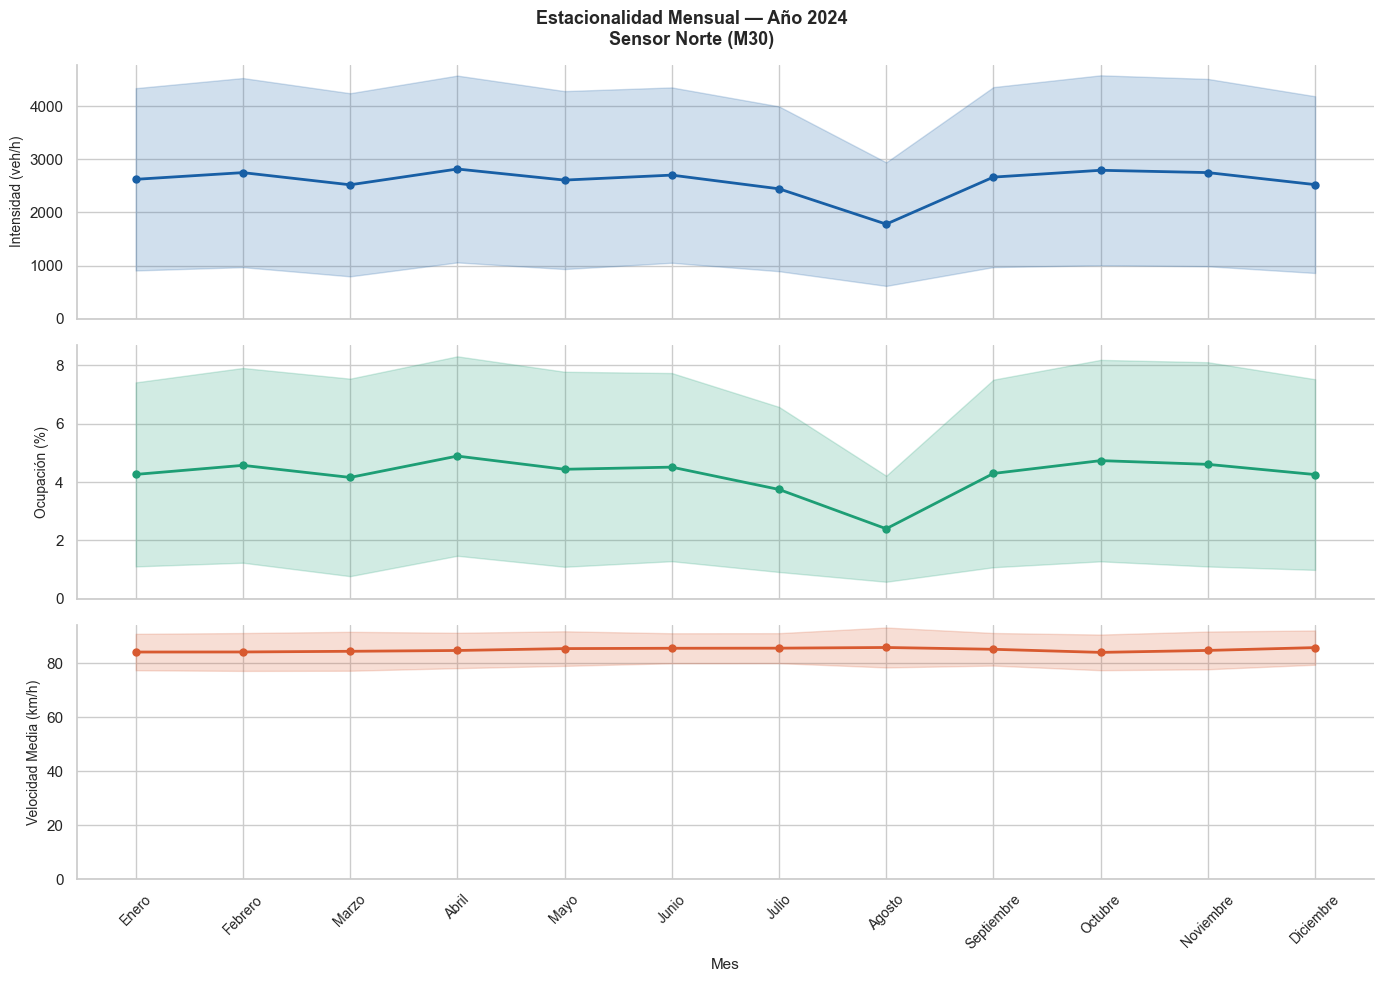

In [9]:
# Visualización Promediando los datos de solo un periodo.
# Estacionalidad Mensual — Primer mes
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Estacionalidad Mensual — Año {primer_anio}\nSensor Norte (M30)',
             fontsize=13, fontweight='bold')

for row, (var, (label, color)) in enumerate(variables.items()):
    ax    = axes[row]
    media = df_anio_agg[(var, 'mean')].values
    std   = df_anio_agg[(var, 'std')].values
    x     = np.arange(1, 13)

    ax.fill_between(x, media - std, media + std, alpha=0.20, color=color)
    ax.plot(x, media, color=color, linewidth=2, marker='o', markersize=5, zorder=3)

    ax.set_ylim(bottom=0)
    ax.set_ylabel(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xticks(range(1, 13))
axes[-1].set_xticklabels(list(meses_map.values()), fontsize=10, rotation=45)
axes[-1].set_xlabel('Mes', fontsize=11)

plt.tight_layout()
plt.show()

Generando visualizaciones sensor Norte...


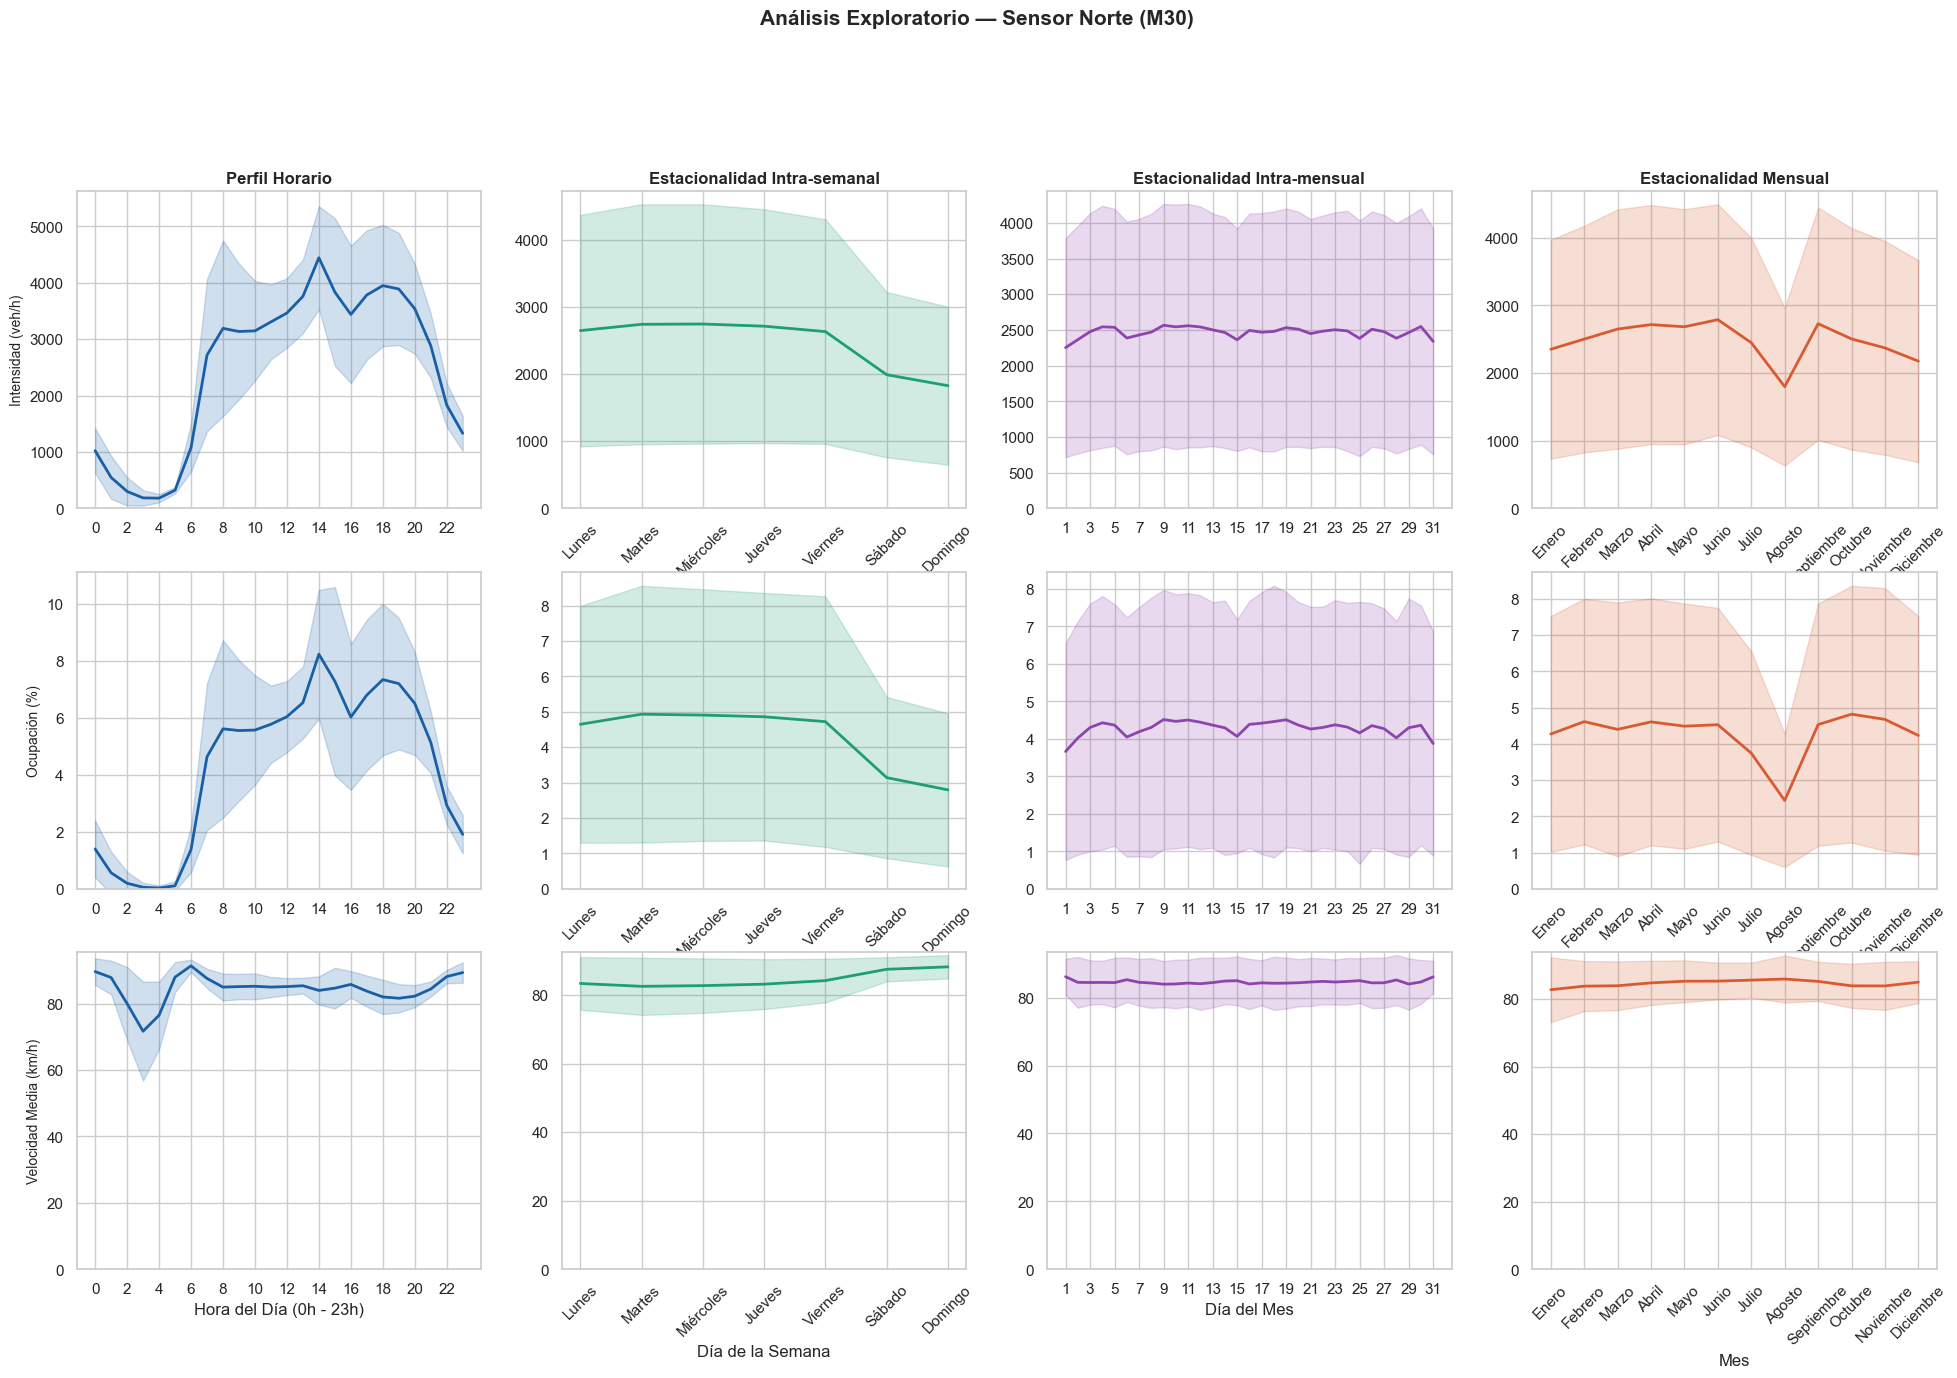

In [10]:
# Visualizaciones promediando todos los datos.
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando visualizaciones sensor Norte...")

sns.set_theme(style="whitegrid", context="notebook")

# --- FILTRO: solo sensor Norte ---
df_norte = df_oro[df_oro['ubicacion'] == 'Norte']

# --- FIGURA: 3 filas x 4 columnas ---
fig, axes = plt.subplots(3, 4, figsize=(24, 14))
fig.suptitle('Análisis Exploratorio — Sensor Norte (M30)', fontsize=15, fontweight='bold', y=1.01)

variables = {
    'intensidad': 'Intensidad (veh/h)',
    'ocupacion':  'Ocupación (%)',
    'vmed':       'Velocidad Media (km/h)'
}

for row, (var, label) in enumerate(variables.items()):

    # --- GRÁFICO 1: Perfil Horario ---
    sns.lineplot(
        data=df_norte,
        x='hora',
        y=var,
        ax=axes[row, 0],
        errorbar='sd',
        linewidth=2,
        color='#185FA5'
    )
    axes[row, 0].set_title('Perfil Horario' if row == 0 else '', fontsize=12, fontweight='bold')
    axes[row, 0].set_xlabel('Hora del Día (0h - 23h)' if row == 2 else '')
    axes[row, 0].set_ylabel(label, fontsize=10)
    axes[row, 0].set_xticks(range(0, 24, 2))
    axes[row, 0].set_ylim(bottom=0)

    # --- GRÁFICO 2: Estacionalidad Intra-semanal ---
    sns.lineplot(
        data=df_norte,
        x='dia_semana',
        y=var,
        ax=axes[row, 1],
        errorbar='sd',
        linewidth=2,
        color='#1D9E75'
    )
    axes[row, 1].set_title('Estacionalidad Intra-semanal' if row == 0 else '', fontsize=12, fontweight='bold')
    axes[row, 1].set_xlabel('Día de la Semana' if row == 2 else '')
    axes[row, 1].set_ylabel('')
    axes[row, 1].tick_params(axis='x', rotation=45)
    axes[row, 1].set_ylim(bottom=0)

    # --- GRÁFICO 3: Estacionalidad Intra-mensual ---
    if 'dia_mes' not in df_norte.columns:
        df_norte = df_norte.copy()
        df_norte['dia_mes'] = df_norte['fecha'].dt.day

    sns.lineplot(
        data=df_norte,
        x='dia_mes',
        y=var,
        ax=axes[row, 2],
        errorbar='sd',
        linewidth=2,
        color='#8E44AD'
    )
    axes[row, 2].set_title('Estacionalidad Intra-mensual' if row == 0 else '', fontsize=12, fontweight='bold')
    axes[row, 2].set_xlabel('Día del Mes' if row == 2 else '')
    axes[row, 2].set_ylabel('')
    axes[row, 2].set_xticks(range(1, 32, 2))
    axes[row, 2].set_ylim(bottom=0)

    # --- GRÁFICO 4: Estacionalidad Mensual ---
    sns.lineplot(
        data=df_norte,
        x='mes',
        y=var,
        ax=axes[row, 3],
        errorbar='sd',
        linewidth=2,
        color='#D85A30'
    )
    axes[row, 3].set_title('Estacionalidad Mensual' if row == 0 else '', fontsize=12, fontweight='bold')
    axes[row, 3].set_xlabel('Mes' if row == 2 else '')
    axes[row, 3].set_ylabel('')
    axes[row, 3].tick_params(axis='x', rotation=45)
    axes[row, 3].set_ylim(bottom=0)

In [30]:
print("Preparando el dataset definitivo para Machine Learning...")

# 1. Seleccionar solo las columnas estrictamente numéricas y necesarias
# Dependiendo se necesite se pueden exportar todas las columnas 
# Todas las columnas, cambia esta línea:
# columnas_modelo = ['id', 'ubicacion', 'fecha', 'intensidad', 'ocupacion', 'vmed', 'dia_semana', 'dia_semana_num', 'hora']

columnas_modelo = ['id', 'fecha', 'intensidad', 'ocupacion', 'vmed', 'mes_num','dia_semana_num', 'hora']
df_final = df_oro[columnas_modelo].reset_index(drop=True)

# 2. Exportar el Parquet (Para los modelos de Python)
ruta_salida_parquet = "../data/processed/dataset_m30_4_sensores_final.parquet"
df_final.to_parquet(ruta_salida_parquet, index=False)
print(f"✅ Dataset Oro exportado a Parquet: {ruta_salida_parquet}")

# 3. Exportar el CSV (Para inspección manual o Excel)
ruta_salida_csv = "../data/processed/dataset_m30_4_sensores_final.csv"
df_final.to_csv(ruta_salida_csv, index=False, sep=';', encoding='utf-8')
print(f"✅ Dataset Oro exportado a CSV: {ruta_salida_csv}")

print("\n--- HITO ALCANZADO ---")
print(f"Dimensiones finales: {df_final.shape}")
print("Las fases de Data Understanding y Data Preparation (CRISP-DM) han finalizado oficialmente.")

Preparando el dataset definitivo para Machine Learning...
✅ Dataset Oro exportado a Parquet: ../data/processed/dataset_m30_4_sensores_final.parquet
✅ Dataset Oro exportado a CSV: ../data/processed/dataset_m30_4_sensores_final.csv

--- HITO ALCANZADO ---
Dimensiones finales: (65485, 8)
Las fases de Data Understanding y Data Preparation (CRISP-DM) han finalizado oficialmente.
